# IEX LOB Reconstruction: Free Market Data Alternative

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Reconstruct a price-level (L2) limit order book from IEX DEEP — the only
free, redistribution-friendly L2 feed at this granularity — and contrast
the resulting book with the order-level (L3) NASDAQ ITCH reconstruction in
`02_itch_lob_reconstruction`.

## Learning Objectives

After completing this notebook, you will be able to:
- Parse IEX DEEP pcap binary into structured messages and explain the
  feed's 11 message types versus ITCH's ~20.
- Maintain a per-price-level book from `PriceLevelUpdate` messages and
  recognize what depth-only feeds cannot tell you (no individual order
  tracking, no per-order cancellation rates).
- Validate the reconstruction (positive spreads, sane depth) and quantify
  what's lost relative to ITCH (queue position, order lifecycles).

## Book reference

Section §3.2 (data-feed taxonomy entry for IEX HIST/DEEP) and §3.3
(notebook is named alongside ITCH and DataBento as a third
reconstruction implementation).

## Prerequisites

- IEX DEEP pcap at
  `data/equities/market/microstructure/iex/deep/*.pcap.gz`
  (downloaded via `data/equities/market/microstructure/iex_download.py --deep --smallest`).

> **Data note (important):** `--smallest` selects IEX's lowest-volume DEEP file
> to keep the download tiny. On the shipped run that file is a non-trading day
> whose only instruments are IEX's internal **test symbols** (ZIEXT, ZEXIT,
> ZXIET) at flat placeholder prices. So the reconstruction, spread, and depth
> statistics below validate the *parser and L2 algorithm* against IEX's
> synthetic test instruments — they are **not** the microstructure of a traded
> security. To reproduce these analyses on a real name, download a full
> trading-day DEEP file (drop `--smallest`) and filter to the symbol of
> interest; the code path is identical.

## IEX vs NASDAQ: Key Differences

| Aspect | NASDAQ ITCH | IEX DEEP |
|--------|-------------|----------|
| LOB granularity | Order-level (L3) | Price-level aggregated (L2) |
| Market share | ~20% | ~3% |
| Speed bump | None | 350μs delay |
| Message types | ~20 | 11 |
| Data access | Licensed | Free public download |

> **Attribution (Required):** Data provided for free by IEX. By accessing or
> using IEX Historical Data, you agree to the
> [IEX Historical Data Terms of Use](https://www.iexexchange.io/legal/hist-data-terms).
>
> **Note on DEEP**: full depth at each price level but without individual
> order IDs — you see total size at each price, but not how many orders
> comprise it.

In [1]:
"""IEX LOB Reconstruction — free market data alternative for limit order book analysis."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import polars as pl

from data import load_iex_hist
from utils.paths import get_output_dir

In [2]:
MAX_MESSAGES = 0  # 0 = all messages
SAVE_PARSED = True  # Save parsed data to output directory

In [3]:
# Paths
OUTPUT_DIR = get_output_dir(3, "iex_deep")

# Normalize MAX_MESSAGES: 0 means no limit
if MAX_MESSAGES == 0:
    MAX_MESSAGES = None

## 1. Load Raw IEX HIST Data

IEX provides HIST data on a T+1 basis, with 12 months of rolling history.
We use the canonical loader to find downloaded pcap files.

**Available feeds:**
- **TOPS** (Top of Book) - Best bid/ask quotes and trades
- **DEEP** (Depth of Book) - Full price-level depth (required for LOB reconstruction)

To download data, run:
```bash
python data/equities/market/microstructure/iex_download.py --deep --smallest
```

In [4]:
# Get raw pcap files from canonical location
deep_files = load_iex_hist(feed="deep", get_raw_files=True)
assert deep_files, (
    "No IEX DEEP data found. Download first:\n"
    "  uv run python data/equities/market/microstructure/iex_download.py --deep --smallest"
)
print(f"Found {len(deep_files)} DEEP file(s):")
for f in deep_files:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name} ({size_mb:.1f} MB)")

try:
    tops_files = load_iex_hist(feed="tops", get_raw_files=True)
    print(f"\nFound {len(tops_files)} TOPS file(s):")
    for f in tops_files:
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name} ({size_mb:.1f} MB)")
except Exception:
    tops_files = []  # TOPS is optional

Found 1 DEEP file(s):
  20180908_IEXTP1_DEEP1.0.pcap.gz (51.0 MB)


## 2. Parse IEX-TP Protocol

IEX uses their own binary protocol (IEX-TP) which wraps message payloads.
The `iex_parser` library handles the low-level decoding.

**DEEP Message Types:**
- `price_level_update` - LOB depth changes at each price level
- `quote_update` - Best bid/ask changes
- `trade_report` - Executed trades

In [5]:
from iex_parser import DEEP_1_0, TOPS_1_6, Parser

print("iex_parser library available")

iex_parser library available


### Extract Symbol from IEX Message

Decode the symbol field from raw bytes or string in an IEX message.

In [6]:
def _extract_symbol(msg: dict) -> str:
    """Decode symbol from raw IEX message (handles bytes and str)."""
    symbol_raw = msg.get("symbol", b"")
    if isinstance(symbol_raw, bytes):
        return symbol_raw.decode().strip()
    return str(symbol_raw).strip()

### Normalize IEX Side Field

IEX encodes the order side in several formats; normalize to "bid" or "ask".

In [7]:
def _normalize_side(msg: dict, side_debug: set) -> str:
    """Normalize the IEX side field to 'bid' or 'ask', tracking raw values for debugging."""
    # Side can be "B"/"S", b"B"/b"S", 0/1, "buy"/"sell", or bytes
    side_raw_orig = msg.get("side", msg.get("msg_flag", ""))
    side_debug.add((type(side_raw_orig).__name__, repr(side_raw_orig)))

    side_raw = side_raw_orig
    if isinstance(side_raw, bytes):
        side_raw = side_raw.decode()
    side_raw = str(side_raw).upper().strip()
    # IEX spec: 0x42='B' (buy side), 0x53='S' (sell side)
    is_bid = side_raw in ("B", "BUY", "0", "66")  # 66 = ord('B')
    return "bid" if is_bid else "ask"

### Dispatch a Single DEEP Message

Route each parsed message to the appropriate buffer based on its type.

In [8]:
def _process_deep_message(msg, symbol_str, trades, quotes, price_levels, side_debug):
    """Dispatch a single DEEP message into the appropriate accumulator list."""
    msg_type = msg.get("type")

    if msg_type == "price_level_update":
        price_levels.append(
            {
                "timestamp": msg["timestamp"],
                "symbol": symbol_str,
                "side": _normalize_side(msg, side_debug),
                "price": float(msg["price"]),
                "size": msg["size"],
            }
        )

    elif msg_type == "quote_update":
        bid = float(msg["bid_price"])
        ask = float(msg["ask_price"])
        if bid > 0 and ask > 0:
            quotes.append(
                {
                    "timestamp": msg["timestamp"],
                    "symbol": symbol_str,
                    "bid_price": bid,
                    "bid_size": msg["bid_size"],
                    "ask_price": ask,
                    "ask_size": msg["ask_size"],
                }
            )

    elif msg_type == "trade_report":
        price = float(msg["price"])
        if price > 0:
            trades.append(
                {
                    "timestamp": msg["timestamp"],
                    "symbol": symbol_str,
                    "price": price,
                    "size": msg["size"],
                }
            )

### Build Result DataFrames

Convert accumulated message buffers into Polars DataFrames for downstream analysis.

In [9]:
def _buffers_to_dataframes(
    trades: list, quotes: list, price_levels: list, total: int, side_debug: set
) -> dict:
    """Package accumulated message buffers into a result dict of DataFrames."""
    return {
        "trades": pl.DataFrame(trades) if trades else pl.DataFrame(),
        "quotes": pl.DataFrame(quotes) if quotes else pl.DataFrame(),
        "price_levels": pl.DataFrame(price_levels) if price_levels else pl.DataFrame(),
        "total_messages": total,
        "side_debug": side_debug,
    }

### Parse IEX DEEP Messages

Extract trades, quotes, and price level updates from raw IEX DEEP pcap files.

In [10]:
def parse_iex_deep(
    pcap_path: Path,
    symbols: list[str] | None = None,
    max_messages: int | None = None,
) -> dict:
    """
    Parse IEX DEEP pcap file into structured DataFrames.

    DEEP provides full depth of book via price_level_update messages,
    plus all TOPS message types (quotes, trades).

    Parameters
    ----------
    pcap_path : Path
        Path to .pcap.gz file (must be DEEP format, not TOPS)
    symbols : list[str], optional
        Filter to specific symbols (e.g., ['AAPL', 'MSFT'])
    max_messages : int, optional
        Stop after N messages (for testing large files)

    Returns
    -------
    dict with keys: 'trades', 'quotes', 'price_levels', 'total_messages'
    """
    trades = []
    quotes = []
    price_levels = []
    total = 0
    side_debug = set()

    symbols_upper = None
    if symbols:
        symbols_upper = {s.upper().strip() for s in symbols}

    with Parser(str(pcap_path), DEEP_1_0) as reader:
        try:
            msg_iter = iter(reader)
        except Exception:
            msg_iter = reader

        while True:
            try:
                msg = next(msg_iter)
            except StopIteration:
                break
            except (ValueError, OSError, EOFError) as e:
                # scapy pcap reader can raise ValueError on Python 3.13+
                # or at EOF in gzipped pcap files — treat as end of stream
                print(f"\n  [Parser] Stopped after {total:,} messages ({type(e).__name__})")
                break

            total += 1

            symbol_str = _extract_symbol(msg)
            if symbols_upper and symbol_str not in symbols_upper:
                continue

            _process_deep_message(msg, symbol_str, trades, quotes, price_levels, side_debug)

            if max_messages and total >= max_messages:
                break

    return _buffers_to_dataframes(trades, quotes, price_levels, total, side_debug)

## 3. Parse DEEP Data

Parse the downloaded DEEP file to extract quotes, trades, and price level updates.

In [11]:
if deep_files:
    pcap_file = deep_files[0]
    print(f"Parsing: {pcap_file.name}")

    data = parse_iex_deep(pcap_file, max_messages=MAX_MESSAGES)

    print(f"\nParsed {data['total_messages']:,} messages")
    print(f"  Quotes: {len(data['quotes']):,}")
    print(f"  Trades: {len(data['trades']):,}")
    print(f"  Price Levels: {len(data['price_levels']):,}")

    # Debug: show what raw side values we saw
    if data.get("side_debug"):
        print(f"\nRaw side values seen: {data['side_debug']}")

    # Show sample of each
    if not data["quotes"].is_empty():
        print("\nSample quotes:")
        print(data["quotes"].head(5))

    if not data["trades"].is_empty():
        print("\nSample trades:")
        print(data["trades"].head(5))

    if not data["price_levels"].is_empty():
        print("\nSample price levels:")
        print(data["price_levels"].head(5))

        # Diagnostic: side distribution
        side_counts = data["price_levels"].group_by("side").agg(pl.len().alias("count"))
        print("\nSide distribution:")
        print(side_counts)
else:
    print("No DEEP files to parse")
    data = None

Parsing: 20180908_IEXTP1_DEEP1.0.pcap.gz



Parsed 1,711,603 messages
  Quotes: 0
  Trades: 387,896
  Price Levels: 1,273,611

Raw side values seen: {('bytes', "b'B'"), ('bytes', "b'S'")}

Sample trades:
shape: (5, 4)
┌────────────────────────────────┬────────┬───────┬──────┐
│ timestamp                      ┆ symbol ┆ price ┆ size │
│ ---                            ┆ ---    ┆ ---   ┆ ---  │
│ datetime[μs, UTC]              ┆ str    ┆ f64   ┆ i64  │
╞════════════════════════════════╪════════╪═══════╪══════╡
│ 2018-09-08 12:36:41.238038 UTC ┆ ZEXIT  ┆ 10.0  ┆ 100  │
│ 2018-09-08 12:44:07.699092 UTC ┆ ZIEXT  ┆ 1.0   ┆ 1200 │
│ 2018-09-08 12:44:07.699092 UTC ┆ ZIEXT  ┆ 1.0   ┆ 100  │
│ 2018-09-08 12:44:07.699092 UTC ┆ ZIEXT  ┆ 1.0   ┆ 100  │
│ 2018-09-08 12:57:02.124110 UTC ┆ ZIEXT  ┆ 1.0   ┆ 100  │
└────────────────────────────────┴────────┴───────┴──────┘

Sample price levels:
shape: (5, 5)
┌────────────────────────────────┬────────┬──────┬────────┬──────┐
│ timestamp                      ┆ symbol ┆ side ┆ price  ┆ size │
│ --- 

## 4. LOB Reconstruction from Price Level Updates

IEX DEEP provides **price-level aggregated** updates, simplifying reconstruction:
- Each `price_level_update` tells you the new total size at a price
- Size of 0 means that price level is removed
- No need to track individual order IDs (unlike ITCH)

In [12]:
class IEXOrderBook:
    """
    Simple limit order book reconstructed from IEX DEEP price level updates.

    Unlike ITCH reconstruction (which tracks individual orders), IEX provides
    aggregated sizes at each price level, simplifying the state machine.
    """

    def __init__(self, symbol: str):
        self.symbol = symbol
        self.bids: dict[float, int] = {}  # price -> size
        self.asks: dict[float, int] = {}  # price -> size
        self.last_update = None

    def update(self, timestamp: int, side: str, price: float, size: int):
        """Apply a price level update."""
        book = self.bids if side == "bid" else self.asks

        if size == 0:
            # Remove price level
            book.pop(price, None)
        else:
            # Update size at price
            book[price] = size

        self.last_update = timestamp

    def best_bid(self) -> tuple[float, int] | None:
        """Return (price, size) of best bid."""
        if not self.bids:
            return None
        price = max(self.bids.keys())
        return (price, self.bids[price])

    def best_ask(self) -> tuple[float, int] | None:
        """Return (price, size) of best ask."""
        if not self.asks:
            return None
        price = min(self.asks.keys())
        return (price, self.asks[price])

    def spread(self) -> float | None:
        """Return bid-ask spread."""
        bid = self.best_bid()
        ask = self.best_ask()
        if bid and ask:
            return ask[0] - bid[0]
        return None

    def midpoint(self) -> float | None:
        """Return midpoint price."""
        bid = self.best_bid()
        ask = self.best_ask()
        if bid and ask:
            return (bid[0] + ask[0]) / 2
        return None

    def depth(self, levels: int = 5) -> dict:
        """Return top N levels on each side."""
        bid_prices = sorted(self.bids.keys(), reverse=True)[:levels]
        ask_prices = sorted(self.asks.keys())[:levels]

        return {
            "bids": [(p, self.bids[p]) for p in bid_prices],
            "asks": [(p, self.asks[p]) for p in ask_prices],
        }

### Capture a Single LOB Snapshot

Record the current book state (best bid/ask, spread, midpoint) at a given timestamp.

In [13]:
def _capture_snapshot(book: IEXOrderBook, timestamp) -> dict:
    """Return a snapshot dict of the current order book state."""
    bid = book.best_bid()
    ask = book.best_ask()
    return {
        "timestamp": timestamp,
        "bid_price": bid[0] if bid else None,
        "bid_size": bid[1] if bid else None,
        "ask_price": ask[0] if ask else None,
        "ask_size": ask[1] if ask else None,
        "spread": book.spread(),
        "midpoint": book.midpoint(),
    }

### Reconstruct LOB Snapshots

Build periodic snapshots from price level updates using the IEXOrderBook state machine.

In [14]:
def reconstruct_lob_snapshots(
    price_levels: pl.DataFrame,
    symbol: str,
    snapshot_interval_sec: float = 1.0,  # 1 second default
) -> pl.DataFrame:
    """
    Reconstruct periodic LOB snapshots from price level updates.

    Parameters
    ----------
    price_levels : pl.DataFrame
        Price level updates for a single symbol
    symbol : str
        Symbol to reconstruct
    snapshot_interval_sec : float
        Seconds between snapshots (default: 1.0)

    Returns
    -------
    DataFrame with columns: timestamp, bid_price, bid_size, ask_price, ask_size,
                           spread, midpoint
    """
    from datetime import timedelta

    # Filter to symbol and sort by time
    df = price_levels.filter(pl.col("symbol") == symbol).sort("timestamp")

    if df.is_empty():
        return pl.DataFrame()

    book = IEXOrderBook(symbol)
    snapshots = []

    # Get first timestamp - could be datetime or nanoseconds
    start_time = df["timestamp"][0]
    snapshot_delta = timedelta(seconds=snapshot_interval_sec)

    # Handle both datetime and integer nanoseconds
    if isinstance(start_time, int):
        # Convert ns integer to datetime
        import datetime as dt

        start_time = dt.datetime.fromtimestamp(start_time / 1e9)
        # Convert column too
        df = df.with_columns(pl.col("timestamp").cast(pl.Datetime("ns")).alias("timestamp"))

    next_snapshot = start_time + snapshot_delta

    for row in df.iter_rows(named=True):
        # Take snapshot if interval elapsed
        while row["timestamp"] >= next_snapshot:
            snapshots.append(_capture_snapshot(book, next_snapshot))
            next_snapshot += snapshot_delta

        # Apply update
        book.update(row["timestamp"], row["side"], row["price"], row["size"])

    return pl.DataFrame(snapshots)

## 5. Reconstruct LOB for Active Symbols

In [15]:
if data and not data["price_levels"].is_empty():
    # Find most active symbols
    symbol_counts = (
        data["price_levels"]
        .group_by("symbol")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    )
    print("Most active symbols (by price level updates):")
    print(symbol_counts.head(10))

    # Reconstruct LOB for top symbol
    top_symbol = symbol_counts["symbol"][0]
    print(f"\nReconstructing LOB for: {top_symbol}")

    snapshots = reconstruct_lob_snapshots(
        data["price_levels"],
        top_symbol,
        snapshot_interval_sec=1.0,  # 1 second
    )

    print(f"Generated {len(snapshots):,} snapshots")
    if not snapshots.is_empty():
        print("\nSample snapshots:")
        print(snapshots.head(10))
else:
    print("No price level data to reconstruct")
    snapshots = pl.DataFrame()
    top_symbol = None

Most active symbols (by price level updates):
shape: (3, 2)
┌────────┬─────────┐
│ symbol ┆ count   │
│ ---    ┆ ---     │
│ str    ┆ u32     │
╞════════╪═════════╡
│ ZIEXT  ┆ 1207722 │
│ ZEXIT  ┆ 64639   │
│ ZXIET  ┆ 1250    │
└────────┴─────────┘

Reconstructing LOB for: ZIEXT


Generated 16,481 snapshots

Sample snapshots:
shape: (10, 7)
┌────────────────────────────────┬───────────┬──────────┬───────────┬──────────┬────────┬──────────┐
│ timestamp                      ┆ bid_price ┆ bid_size ┆ ask_price ┆ ask_size ┆ spread ┆ midpoint │
│ ---                            ┆ ---       ┆ ---      ┆ ---       ┆ ---      ┆ ---    ┆ ---      │
│ datetime[μs, UTC]              ┆ f64       ┆ i64      ┆ f64       ┆ i64      ┆ f64    ┆ f64      │
╞════════════════════════════════╪═══════════╪══════════╪═══════════╪══════════╪════════╪══════════╡
│ 2018-09-08 12:38:11.554603 UTC ┆ null      ┆ null     ┆ 1.01      ┆ 1100     ┆ null   ┆ null     │
│ 2018-09-08 12:38:12.554603 UTC ┆ null      ┆ null     ┆ 1.01      ┆ 1100     ┆ null   ┆ null     │
│ 2018-09-08 12:38:13.554603 UTC ┆ null      ┆ null     ┆ 1.01      ┆ 1100     ┆ null   ┆ null     │
│ 2018-09-08 12:38:14.554603 UTC ┆ null      ┆ null     ┆ 1.01      ┆ 1100     ┆ null   ┆ null     │
│ 2018-09-08 12:38:15.554603 U

In [16]:
# Check data completeness
if not snapshots.is_empty():
    valid_spreads = snapshots.filter(pl.col("spread").is_not_null())
    valid_midpoints = snapshots.filter(pl.col("midpoint").is_not_null())

    print("Data completeness:")
    print(
        f"  Snapshots with spread: {len(valid_spreads):,} ({100 * len(valid_spreads) / len(snapshots):.1f}%)"
    )
    print(
        f"  Snapshots with midpoint: {len(valid_midpoints):,} ({100 * len(valid_midpoints) / len(snapshots):.1f}%)"
    )

    if not valid_spreads.is_empty():
        print("\nSpread statistics:")
        print(f"  Min: ${valid_spreads['spread'].min():.4f}")
        print(f"  Mean: ${valid_spreads['spread'].mean():.4f}")
        print(f"  Max: ${valid_spreads['spread'].max():.4f}")
    else:
        print("\nWARNING: No valid spread data - order book may be one-sided")

Data completeness:
  Snapshots with spread: 12,577 (76.3%)
  Snapshots with midpoint: 12,577 (76.3%)

Spread statistics:
  Min: $0.0001
  Mean: $0.0887
  Max: $0.2600


## 6. Save Parsed Data to Canonical Location

Save the parsed data so it can be loaded directly via `load_iex_hist()`.

In [17]:
if data and SAVE_PARSED:
    # Extract date from filename (e.g., 20180908_IEXTP1_DEEP1.0.pcap.gz)
    date_str = pcap_file.name.split("_")[0]

    # Save each data type to OUTPUT_DIR
    for dtype, parsed_df in [
        ("quotes", data["quotes"]),
        ("trades", data["trades"]),
        ("price_levels", data["price_levels"]),
    ]:
        if not parsed_df.is_empty():
            type_dir = OUTPUT_DIR / dtype
            type_dir.mkdir(parents=True, exist_ok=True)
            output_path = type_dir / f"{date_str}.parquet"
            parsed_df.write_parquet(output_path)
            print(f"Saved {len(parsed_df):,} rows to {output_path}")

    print(f"\nData saved to: {OUTPUT_DIR}")
else:
    print("Skipping save (SAVE_PARSED=False or no data)")

Saved 387,896 rows to /home/stefan/ml4t/code/03_market_microstructure/output/iex_deep/trades/20180908.parquet
Saved 1,273,611 rows to /home/stefan/ml4t/code/03_market_microstructure/output/iex_deep/price_levels/20180908.parquet

Data saved to: /home/stefan/ml4t/code/03_market_microstructure/output/iex_deep


## 7. Visualization: LOB Evolution

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utils.style import COLORS

if not snapshots.is_empty() and top_symbol:
    # Filter to rows with valid midpoint and spread (need both bid and ask for these)
    valid_snapshots = snapshots.filter(
        pl.col("midpoint").is_not_null() & pl.col("spread").is_not_null()
    )

    print(f"Total snapshots: {len(snapshots):,}")
    print(f"Valid snapshots (with midpoint/spread): {len(valid_snapshots):,}")

    if valid_snapshots.is_empty():
        print("\nWARNING: No valid snapshots to visualize.")
        print("This can happen when the order book only has one side (bids or asks, not both).")
        print("Test symbols like ZIEXT/ZEXIT may not have two-sided markets.")

        # Show what we do have
        has_bid = snapshots.filter(pl.col("bid_price").is_not_null())
        has_ask = snapshots.filter(pl.col("ask_price").is_not_null())
        print(f"\nSnapshots with bids: {len(has_bid):,}")
        print(f"Snapshots with asks: {len(has_ask):,}")
else:
    print("No snapshots to visualize")

Total snapshots: 16,481
Valid snapshots (with midpoint/spread): 12,577


In [19]:
if not snapshots.is_empty() and top_symbol:
    valid_snapshots = snapshots.filter(
        pl.col("midpoint").is_not_null() & pl.col("spread").is_not_null()
    )

    if not valid_snapshots.is_empty():
        # Timestamps are already datetime
        snapshots_plot = valid_snapshots.with_columns(pl.col("timestamp").alias("time"))
    else:
        snapshots_plot = pl.DataFrame()

In [20]:
if not snapshots.is_empty() and top_symbol and not snapshots_plot.is_empty():
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=(f"{top_symbol} Midpoint", "Bid-Ask Spread"),
        vertical_spacing=0.1,
    )

    # Midpoint
    fig.add_trace(
        go.Scatter(
            x=snapshots_plot["time"].to_list(),
            y=snapshots_plot["midpoint"].to_list(),
            mode="lines",
            name="Midpoint",
            line=dict(color=COLORS["blue"], width=1.5),
        ),
        row=1,
        col=1,
    )

    # Spread
    fig.add_trace(
        go.Scatter(
            x=snapshots_plot["time"].to_list(),
            y=snapshots_plot["spread"].to_list(),
            mode="lines",
            name="Spread",
            line=dict(color=COLORS["amber"], width=1.5),
            fill="tozeroy",
            fillcolor="rgba(212, 168, 75, 0.2)",
        ),
        row=2,
        col=1,
    )

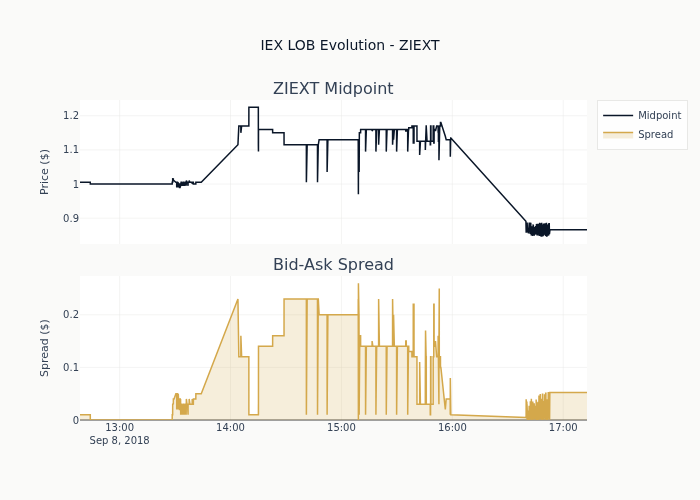

In [21]:
if not snapshots.is_empty() and top_symbol and not snapshots_plot.is_empty():
    fig.update_layout(
        title=f"IEX LOB Evolution - {top_symbol}",
        height=500,
        showlegend=True,
        template="ml4t",
    )

    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Spread ($)", row=2, col=1)

    fig.show()

## 8. Key Takeaways: IEX vs ITCH

| Concept | ITCH Approach | IEX DEEP Approach |
|---------|---------------|-------------------|
| **LOB State** | Track individual orders (Add/Modify/Delete) | Update aggregated price levels |
| **Trade Attribution** | Match execute messages to orders | Direct trade reports |
| **Message Volume** | Very high (~millions/day) | Lower (~100k-1M/day) |
| **Complexity** | Higher (order lifecycle tracking) | Lower (level updates) |
| **Use Case** | HFT research, order flow analysis | General microstructure, spread analysis |

**Bottom line:** IEX HIST is a free, redistribution-friendly L2 feed that
supports the LOB-dynamics, spread, and basic-microstructure analyses in this
notebook. It does not provide order-level (L3) granularity, so per-order
cancellation rates and queue-position questions require ITCH or DataBento.
(Recall the data note above: the numbers here come from IEX test symbols on the
`--smallest` file, so they exercise the pipeline rather than describe a traded
security — rerun on a full trading-day file for real spread/depth figures.)

---

> **Attribution:** Data provided for free by IEX. By accessing or using IEX Historical
> Data, you agree to the [IEX Historical Data Terms of Use](https://www.iexexchange.io/legal/hist-data-terms).

## References

- [IEX HIST Data Download](https://iextrading.com/trading/market-data/)
- [IEX DEEP Specification](https://iextrading.com/docs/IEX%20DEEP%20Specification.pdf)
- [iex_parser Python Library](https://github.com/rob-blackbourn/iex_parser)
- [IEX Historical Data Terms](https://www.iexexchange.io/legal/hist-data-terms)